# Minimal EnergyPlus 23.2 ↔ Python BRCM comparison

This notebook develops the workflow one stage at a time: run EnergyPlus, generate the BRCM thermal network, configure external heat-flux (EHF) models, map EnergyPlus columns to BRCM identifiers, compose the BuildingModel, simulate, and compare. The IDF defines the RC network but does not by itself define BRCM forcing trajectories.

In [1]:
from pathlib import Path
import re, shutil, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

REPO = Path.cwd().parents[1]
EPD = Path.cwd().parents[3] / '_phd' / 'Y3'
REPO = Path.cwd().parents[1]
EPD = Path.cwd().parents[3] / '2025'
sys.path[:0] = [str(REPO / 'src'), str(EPD / 'src')]
from ReIDF import IDFout, run_IDF, md_IDFdt
import brcm

CASE_NAME = '1ZoneUncontrolled1'
IDF = REPO / '_E+' / f'{CASE_NAME}.idf'
IDD = REPO / '_E+/idd/23.2/Energy+.idd'
EPW = EPD / 'src' / '_base/epw/ED-TMYx.2023.epw'
ENERGYPLUS = Path('/Applications/EnergyPlus-23-2-0/energyplus') if sys.platform == 'darwin' else Path('C:/EnergyPlusV23-2-0/EnergyPlus.exe')
WORK = REPO / 'pre_test/outputs/validation/eplus_23_2_minimal' / CASE_NAME
WORK.mkdir(parents=True, exist_ok=True)
TS_HRS = 0.25
PERIODS = {
    'January': ('2023-01-01', '2023-01-05'),
    'April': ('2023-04-01', '2023-04-05'),
    'July': ('2023-07-01', '2023-07-05'),
    'October': ('2023-10-01', '2023-10-05'),
}
START_DATE, END_DATE = PERIODS['April']  # Step-by-step worked example below.

## 1 — Run EnergyPlus and export forcing/validation variables

EnergyPlus is run first to provide a common weather period, gain signals, and validation trajectories. Some outputs become BRCM forcing inputs; others are diagnostics only. Surface temperatures must not drive the final independent comparison.

The disposable copy is changed to a weather-only run. `md_IDFdt()` sets the requested RunPeriod, while `SimulationControl` is changed from design-day-only to weather-file-only so sizing environments cannot be concatenated into the CSV.

In [2]:
working_idf = WORK / IDF.name
shutil.copy2(IDF, working_idf)
md_IDFdt(working_idf, start_date=START_DATE, end_date=END_DATE)

lines = working_idf.read_text(encoding='utf-8').splitlines(keepends=True)
start = next(i for i, line in enumerate(lines) if line.strip().casefold().startswith('simulationcontrol,'))
fields, index = [], start + 1
while index < len(lines):
    fields.append(index)
    if ';' in lines[index]: break
    index += 1
for position, value in ((3, 'No'), (4, 'Yes')):
    row = fields[position]
    lines[row] = re.sub(r'^(\s*)(?:Yes|No)(\s*[,;])', rf'\g<1>{value}\g<2>', lines[row], flags=re.I)
working_idf.write_text(''.join(lines), encoding='utf-8')

window_data = (ENERGYPLUS.parent / 'DataSets' / 'Window5DataFile.dat').resolve()
text = working_idf.read_text(encoding='utf-8').replace(r'..\datasets\Window5DataFile.dat', str(window_data))
working_idf.write_text(text, encoding='utf-8')
with working_idf.open('a', encoding='utf-8') as stream:
    stream.write(r'''
Output:Variable,*,Site Outdoor Air Drybulb Temperature,timestep;
Output:Variable,*,Site Ground Temperature,timestep;
Output:Variable,*,Site Direct Solar Radiation Rate per Area,timestep;
Output:Variable,*,Site Diffuse Solar Radiation Rate per Area,timestep;
Output:Variable,*,Zone Mean Air Temperature,timestep;
Output:Variable,*,Surface Inside Face Temperature,timestep;
Output:Variable,*,Surface Outside Face Temperature,timestep;
Output:Variable,*,Surface Inside Face Convection Heat Transfer Coefficient,timestep;
Output:Variable,*,Surface Outside Face Convection Heat Transfer Coefficient,timestep;
Output:Variable,*,Surface Outside Face Thermal Radiation to Sky Heat Transfer Coefficient,timestep;
Output:Variable,*,Surface Outside Face Thermal Radiation to Ground Heat Transfer Coefficient,timestep;
Output:Variable,*,Surface Outside Face Net Thermal Radiation Heat Gain Rate,timestep;
Output:Variable,*,Surface Outside Face Incident Solar Radiation Rate per Area,timestep;
Output:Variable,*,Surface Outside Face Solar Radiation Heat Gain Rate,timestep;
Output:Variable,*,Surface Window Transmitted Solar Radiation Rate,timestep;
Output:Variable,*,Surface Window Net Heat Transfer Rate,timestep;
Output:Variable,*,Zone Windows Total Transmitted Solar Radiation Rate,timestep;
Output:Variable,*,Zone Total Internal Convective Heating Rate,timestep;
Output:Variable,*,Zone Total Internal Radiant Heating Rate,timestep;
Output:Variable,*,Zone Air Heat Balance Outdoor Air Transfer Rate,timestep;
Output:Variable,*,Zone Air Heat Balance Surface Convection Rate,timestep;
Output:Variable,*,Zone Air Heat Balance Internal Convective Heat Gain Rate,timestep;
Output:Variable,*,Zone Air Heat Balance Air Energy Storage Rate,timestep;
''')
IDFout(working_idf, ['CSV', 'MTR', 'Tabular', 'RDD'])
eplus_dir = Path(run_IDF(working_idf, EPW, ENERGYPLUS))
eplus = pd.read_csv(eplus_dir / 'eplusout.csv')
time_col = next(column for column in eplus if 'date/time' in column.casefold().replace(' ', ''))
print(f'EnergyPlus: {len(eplus)} samples, {len(eplus.columns) - 1} signals')

Simulation completed successfully.
Simulation Output Folder: C:\Users\s2589602\Downloads\2026\BRCMToolbox_adapted\pre_test\outputs\validation\eplus_23_2_minimal\1ZoneUncontrolled1\1ZoneUncontrolled1
EnergyPlus: 480 samples, 72 signals


## 2 — Generate the BRCM ThermalModel from the IDF

This stage creates only `dx/dt = A x + Bq q`. `A` is in s⁻¹, `Bq` is K/J, and `Xcap` is J/K. State and heat-flux ordering is given by the model identifiers. Ambient temperature, solar gains, internal gains, HVAC, and trajectories are not yet defined.

In [3]:
conversion = brcm.convert_idf_to_brcm_data(IDF, idd_path=IDD)
thermal_data = brcm.conversion_to_thermal_model_data(conversion)
thermal_model = brcm.generate_thermal_model(thermal_data)

## 3 — Configure the EHF models

All EHF constructors use `(thermal_data, thermal_model, identifier, source_file)`.

| EHF class | Generated signal | Expected units | Convention |
|---|---|---|---|
| `InternalGains` | `v_IG_<name>` | W/m² | multiplied by zone floor area |
| `BuildingHull` | `v_Tamb`, optional `v_Tgnd`, `v_solGlobFac_<name>` | °C and W/m² | ambient conduction, solar, windows and infiltration |
| `Radiators` | `u_rad_<name>` | W/m² | positive heating |
| `BEHeatfluxes` | `u_BEH_<name>_heat/cool` | W/m² | targets a one-based massive layer |
| `AHU` | identifier-prefixed mass flow/heating/cooling | kg/s, W, °C | mass-flow × temperature terms are bilinear |

This uncontrolled example uses `BuildingHull` and `InternalGains`. Window incident irradiance is an input; EnergyPlus transmitted-solar and net-window-heat columns remain validation signals. Opaque solar is unavailable here because the outdoor constructions are massless and the Python opaque-solar path requires a massive envelope state.

In [4]:
ehf_dir = WORK / 'ehf'
ehf_dir.mkdir(parents=True, exist_ok=True)
window_elements = [element for element in thermal_data.building_elements if element.window_identifier]
ep_window_by_parent = {window.parent_surface.casefold(): window for window in conversion.normalized_model.windows}
hull_rows = ['facade_solar_group;buildingelement_identifier;disturbance_identifier;absorptance;', 'window_solar_group;buildingelement_identifier;disturbance_identifier;control_identifier;secondary_gains_fraction;']
for element in window_elements:
    hull_rows.append(f';{element.identifier};{element.identifier};;1;')
hull_rows.append('infiltration_specification;zone_identifier;airchangerate;;;')
for zone in thermal_data.zones:
    hull_rows.append(f';{zone.identifier};0;;;')
hull_file = ehf_dir / 'building_hull.csv'
hull_file.write_text('\n'.join(hull_rows) + '\n', encoding='utf-8')
gains_file = ehf_dir / 'internal_gains.csv'
gains_file.write_text('zone_identifier;disturbance_identifier;\n' + ''.join(f'{zone.identifier};{zone.identifier};\n' for zone in thermal_data.zones), encoding='utf-8')
building_hull = brcm.BuildingHull(thermal_data, thermal_model, 'hull', hull_file)
internal_gains = brcm.InternalGains(thermal_data, thermal_model, 'gains', gains_file)
ehf_models = [building_hull, internal_gains]
[(model.EHF_identifier, model.identifiers.u, model.identifiers.v) for model in ehf_models]

[('hull', [], ['v_Tamb', 'v_solGlobFac_B0001']), ('gains', [], ['v_IG_Z0001'])]

## 4 — Map EnergyPlus outputs to EHF inputs

Mapping is performed by identifier rather than matrix position. Temperature columns remain °C. Internal convective plus radiant heat is exported in W and divided by zone area because `InternalGains` expects W/m²; the EHF multiplies it by area to recover W. No manual W→J conversion is required because discretization integrates W over seconds through `Bq` in K/J.

In [5]:
def ep_column(variable, key=None):
    matches = [column for column in eplus if variable.casefold() in column.casefold() and (key is None or f'{key}:{variable}'.casefold() in column.casefold())]
    if len(matches) != 1: raise KeyError(f'Expected one column for {key!r}/{variable!r}; found {matches}')
    return matches[0]

forcing_by_identifier = {'v_Tamb': eplus[ep_column('Site Outdoor Air Drybulb Temperature')].to_numpy(float)}
mapping_rows = [('v_Tamb', ep_column('Site Outdoor Air Drybulb Temperature'), '°C', 'positive ambient conductance')]
if 'v_Tgnd' in building_hull.identifiers.v:
    forcing_by_identifier['v_Tgnd'] = eplus[ep_column('Site Ground Temperature')].to_numpy(float)
for element in window_elements:
    parent = element.description.split(':', 1)[1]
    ep_window = ep_window_by_parent[parent.casefold()]
    column = ep_column('Surface Outside Face Incident Solar Radiation Rate per Area', ep_window.name)
    identifier = f'v_solGlobFac_{element.identifier}'
    forcing_by_identifier[identifier] = eplus[column].to_numpy(float)
    mapping_rows.append((identifier, column, 'W/m²', 'positive solar gain'))
for zone in thermal_data.zones:
    convective = ep_column('Zone Total Internal Convective Heating Rate', zone.description)
    radiant = ep_column('Zone Total Internal Radiant Heating Rate', zone.description)
    identifier = f'v_IG_{zone.identifier}'
    forcing_by_identifier[identifier] = (eplus[convective].to_numpy(float) + eplus[radiant].to_numpy(float)) / thermal_data.eval_str(zone.area)
    mapping_rows.append((identifier, f'{convective} + {radiant}', 'W → W/m²', 'positive internal gain'))
display(pd.DataFrame(mapping_rows, columns=['BRCM identifier', 'EnergyPlus source', 'units', 'sign']))

,BRCM identifier,EnergyPlus source,units,sign
0,v_Tamb,Environment:Site Outdoor Air Drybulb Temperatu...,°C,positive ambient conductance
1,v_solGlobFac_B0001,ZN001:WALL001:WIN001:Surface Outside Face Inci...,W/m²,positive solar gain
2,v_IG_Z0001,ZONE ONE:Zone Total Internal Convective Heatin...,W → W/m²,positive internal gain


## 5 — Generate the BuildingModel

The BuildingModel composes the existing ThermalModel with the EHF instances. Its sorted identifier lists define row order in `U` and `V`; trajectories always use identifiers on rows and time on columns. Sampling time is expressed in hours.

In [6]:
building_model = brcm.BuildingModel(thermal_model, ehf_models)
building_model.discretize(TS_HRS)
missing = set(building_model.identifiers.v) - set(forcing_by_identifier)
extra = set(forcing_by_identifier) - set(building_model.identifiers.v)
if missing or extra: raise RuntimeError(f'Forcing mismatch: missing={missing}, extra={extra}')
U = np.zeros((len(building_model.identifiers.u), len(eplus)))
V = np.vstack([forcing_by_identifier[name] for name in building_model.identifiers.v])
print('u row order:', building_model.identifiers.u, U.shape)
print('v row order:', building_model.identifiers.v, V.shape)

u row order: [] (0, 480)
v row order: ['v_IG_Z0001', 'v_Tamb', 'v_solGlobFac_B0001'] (3, 480)


## 6 — Simulate BRCM independently

All states begin at the first EnergyPlus zone-air temperature, and each zone state is set to its matching value. The run is open loop: EnergyPlus surface or future zone temperatures are not fed back into BRCM.

In [7]:
zone_pairs = [(zone.identifier, zone.description, ep_column('Zone Mean Air Temperature', zone.description)) for zone in thermal_data.zones]
x_index = {name: index for index, name in enumerate(building_model.identifiers.x)}
initial_temperature = np.mean([eplus[column].iloc[0] for _, _, column in zone_pairs])
x0 = np.full((len(building_model.identifiers.x), 1), initial_temperature)
for zone_id, _, column in zone_pairs:
    x0[x_index[f'x_{zone_id}'], 0] = eplus[column].iloc[0]
brcm_run = brcm.simulate_building_model(building_model, x0, U, V)
print('BRCM X:', brcm_run.X.shape, 'finite:', np.isfinite(brcm_run.X).all())

BRCM X: (2, 480) finite: True


## 7 — Compare against EnergyPlus

This is the independent comparison. Remaining differences can include omitted opaque solar on massless constructions, dynamic EnergyPlus exterior films and long-wave exchange, simplified radiant-gain distribution, and infiltration assumptions.

### Diagnostic decomposition (no calibration)

After the four seasonal plots, the April case is decomposed into initial-condition, exterior boundary, solar, window, internal-gain, infiltration, construction/mass, and zone-air heat-balance terms. EnergyPlus heat-balance outputs are diagnostics only and are never fed back into BRCM. The final evidence table ranks causes without changing any model parameter.

Simulation completed successfully.
Simulation Output Folder: C:\Users\s2589602\Downloads\2026\BRCMToolbox_adapted\pre_test\outputs\validation\eplus_23_2_minimal\1ZoneUncontrolled1\seasonal\january\1ZoneUncontrolled1
Simulation completed successfully.
Simulation Output Folder: C:\Users\s2589602\Downloads\2026\BRCMToolbox_adapted\pre_test\outputs\validation\eplus_23_2_minimal\1ZoneUncontrolled1\seasonal\april\1ZoneUncontrolled1
Simulation completed successfully.
Simulation Output Folder: C:\Users\s2589602\Downloads\2026\BRCMToolbox_adapted\pre_test\outputs\validation\eplus_23_2_minimal\1ZoneUncontrolled1\seasonal\july\1ZoneUncontrolled1
Simulation completed successfully.
Simulation Output Folder: C:\Users\s2589602\Downloads\2026\BRCMToolbox_adapted\pre_test\outputs\validation\eplus_23_2_minimal\1ZoneUncontrolled1\seasonal\october\1ZoneUncontrolled1


,Season,Mean bias [K],RMSE [K],MAE [K],Max |error| [K]
0,January,-0.126,0.750,0.553,2.164
1,April,-2.274,2.838,2.326,5.159
2,July,-2.783,3.270,2.843,5.750
3,October,0.161,1.162,0.982,2.518


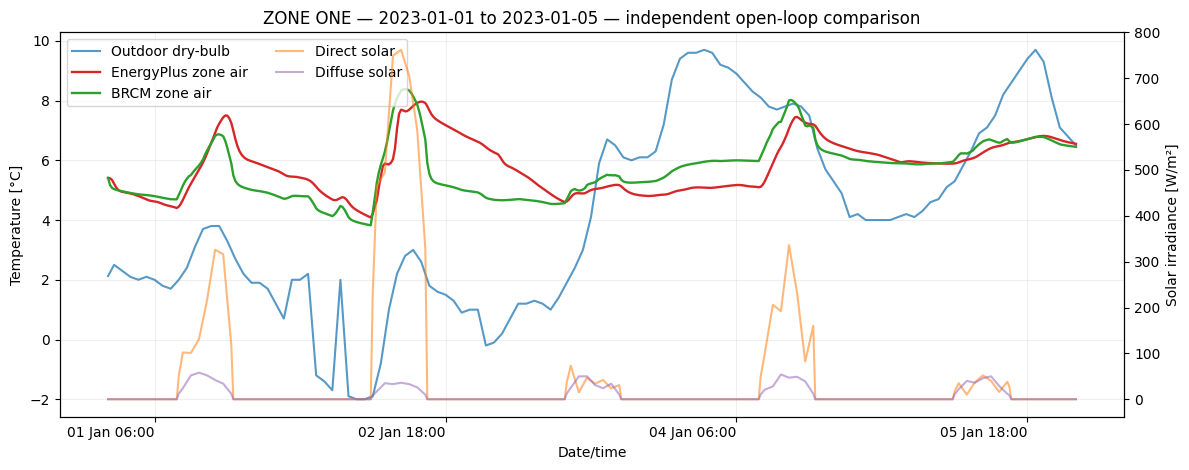

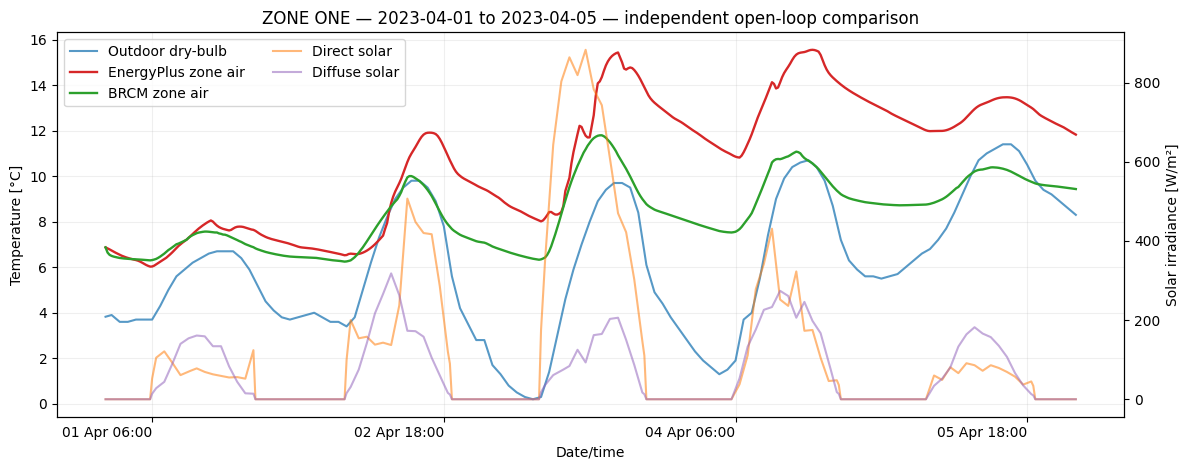

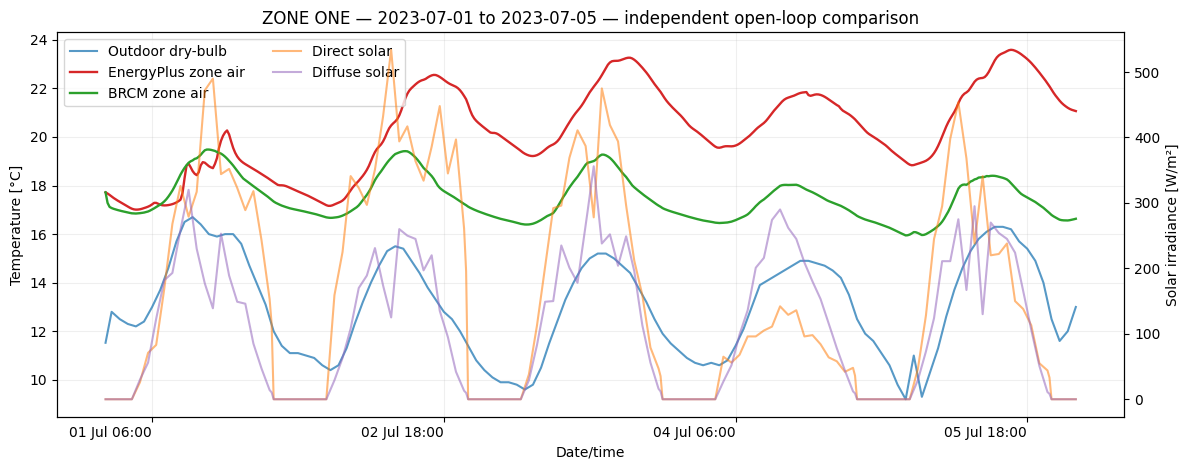

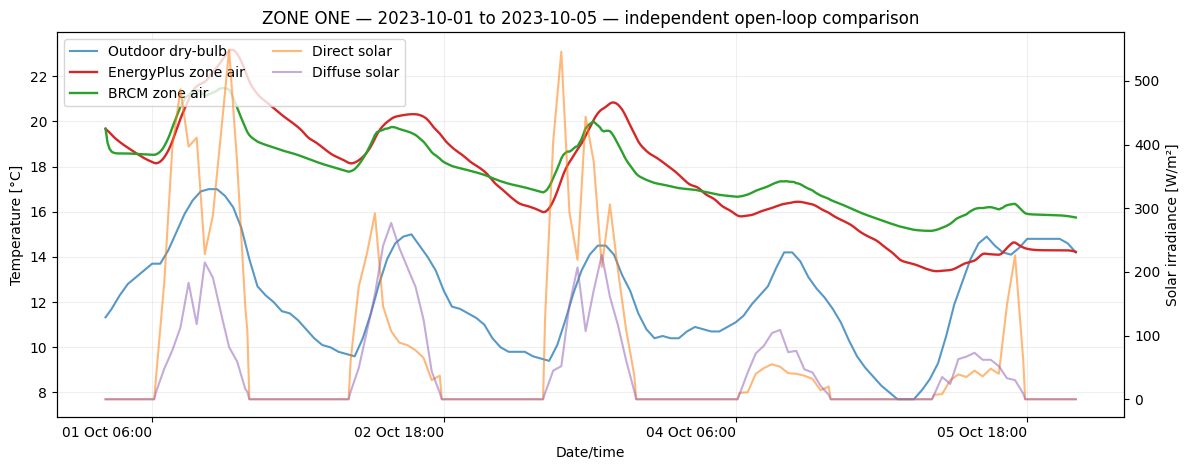

T_zone_EP(t0): 6.871467777437646
T_zone_BRCM(t0): 6.871467777437646
min/max BRCM x0: 6.871467777437646 6.871467777437646


,temperature at t0 [°C]
ZN001:WALL001:Surface Inside Face Temperature,6.554359
ZN001:WALL002:Surface Inside Face Temperature,6.547673
ZN001:WALL003:Surface Inside Face Temperature,6.540346
ZN001:WALL004:Surface Inside Face Temperature,6.539709
ZN001:FLR001:Surface Inside Face Temperature,7.215368
ZN001:ROOF001:Surface Inside Face Temperature,6.667226
ZN001:WALL001:WIN001:Surface Inside Face Temperature,5.374411
ZN001:WALL001:Surface Outside Face Temperature,2.914433
ZN001:WALL002:Surface Outside Face Temperature,2.916845
ZN001:WALL003:Surface Outside Face Temperature,2.814906


,Surface,BRCM fixed exterior h [W/m²K],BRCM total path G [W/K],EP h_conv min,EP h_conv max,EP h_sky mean,EP h_ground mean
0,Zn001:Wall001,12.5,23.740,1.559,1000.0,1.504,2.275
1,Zn001:Wall002,12.5,27.718,1.718,1000.0,1.489,2.253
2,Zn001:Wall003,12.5,27.718,1.644,1000.0,1.473,2.230
3,Zn001:Wall004,12.5,27.718,1.559,1000.0,1.492,2.257
4,Zn001:Roof001,12.5,41.028,1.758,1000.0,4.201,0.000


,Model,window area [m²],U-value [W/m²K],SHGC/g-value,frame/divider
0,BRCM converted,10.0,1.000,0.500,0.0
1,EnergyPlus glass construction,10.0,2.674,0.775,frame/divider modelled separately


Internal gains peak convective/radiant [W]: 0.0 0.0
Outdoor-air transfer min/max [W]: 0.0 0.0 (BRCM infiltration configured as 0 ACH)


,Surface,EP area [m²],BRCM area [m²],area match,construction,EP layer U [W/m²K],BRCM layer U [W/m²K],U match,layers: thickness/R/density/cp,derived EP material C [J/K],BRCM C [J/K],boundary,capacitance match
0,Zn001:Wall001,69.68,69.67728,True,R13WALL,0.436,0.436497,True,"R13LAYER: t=0 m, R=2.29096, rho=nan, cp=nan",0.000000e+00,0.000000e+00,ambient,True
1,Zn001:Wall002,69.68,69.67728,True,R13WALL,0.436,0.436497,True,"R13LAYER: t=0 m, R=2.29096, rho=nan, cp=nan",0.000000e+00,0.000000e+00,ambient,True
2,Zn001:Wall003,69.68,69.67728,True,R13WALL,0.436,0.436497,True,"R13LAYER: t=0 m, R=2.29096, rho=nan, cp=nan",0.000000e+00,0.000000e+00,ambient,True
3,Zn001:Wall004,69.68,69.67728,True,R13WALL,0.436,0.436497,True,"R13LAYER: t=0 m, R=2.29096, rho=nan, cp=nan",0.000000e+00,0.000000e+00,ambient,True
4,Zn001:Flr001,232.26,232.25760,True,FLOOR,17.040,17.040167,True,"C5 - 4 IN HW CONCRETE: t=0.1015 m, R=0.0586849...",4.423913e+07,4.423913e+07,adiabatic,True
5,Zn001:Roof001,232.26,232.25760,True,ROOF31,0.183,0.183284,True,"R31LAYER: t=0 m, R=5.456, rho=nan, cp=nan",0.000000e+00,0.000000e+00,ambient,True


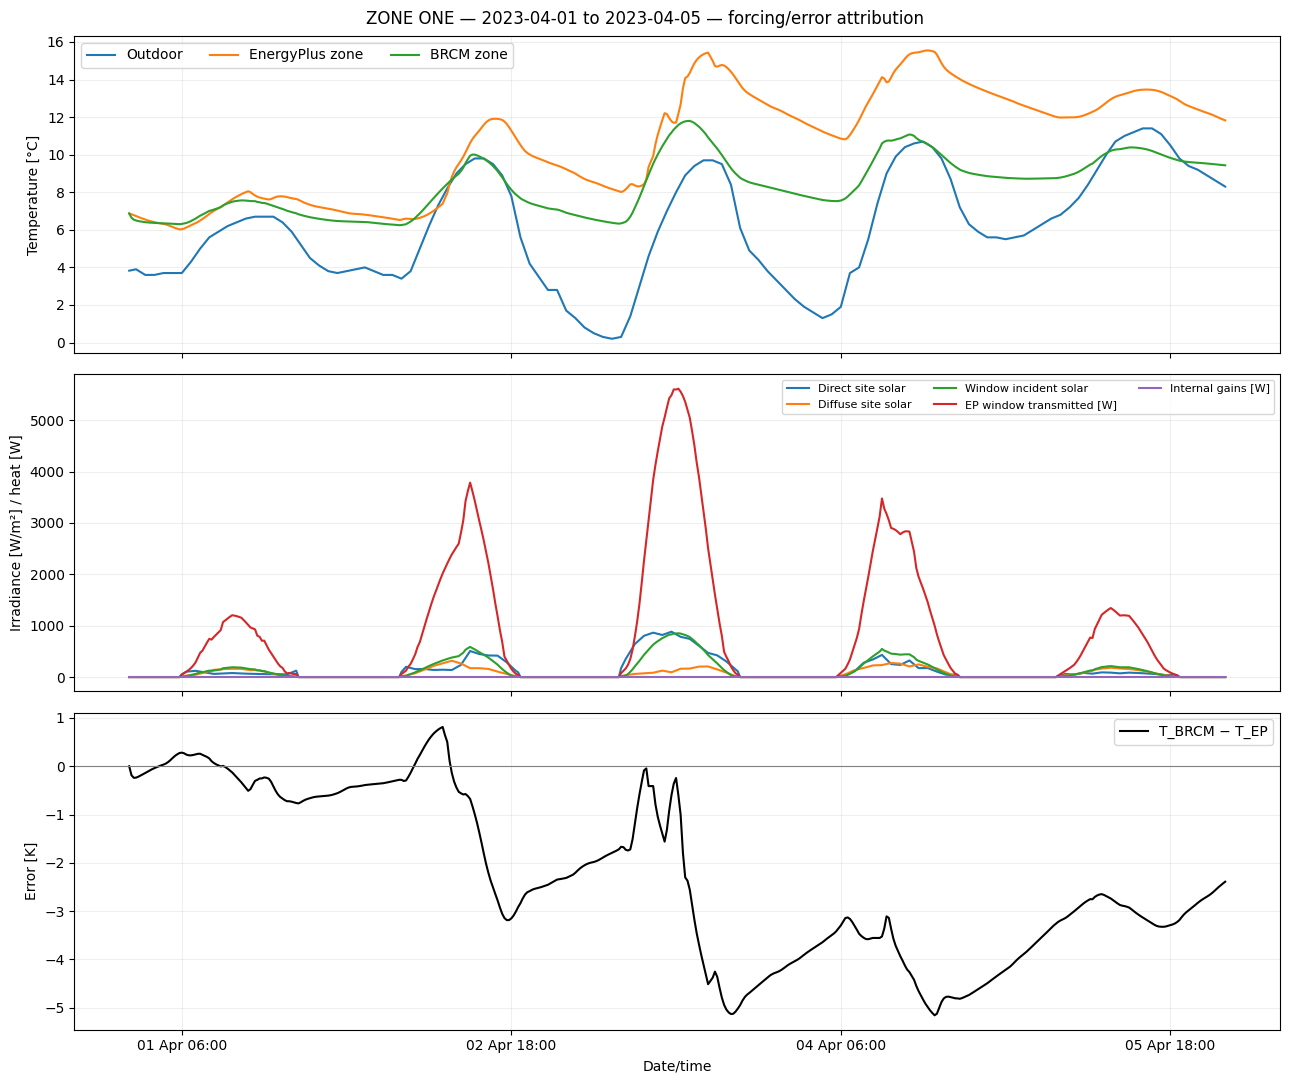

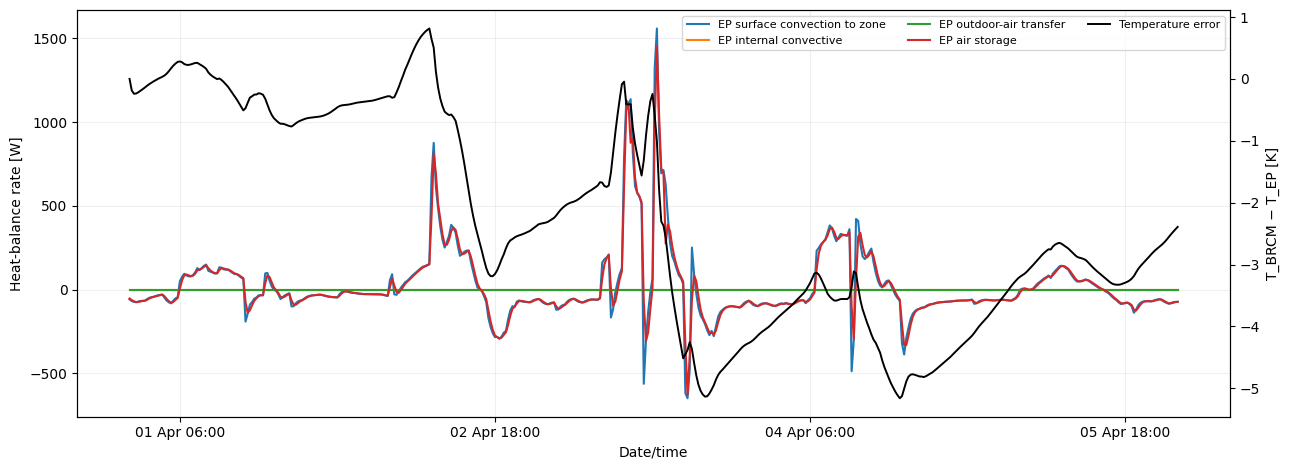

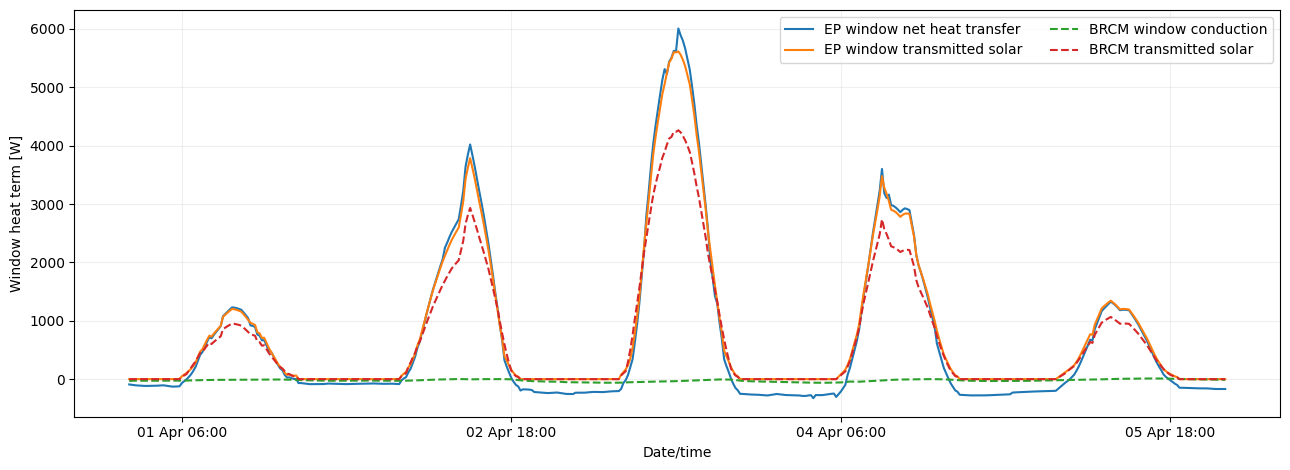

,Potential cause,Evidence,Magnitude / correlation with error,Status
0,Initial conditions,Zone states equal at t0; EP surface temperatur...,"max surface−zone offset 6.40 K; corr(error, EP...",Likely contributor to early decay
1,Solar mapping,BRCM uses window-specific incident irradiation...,EP opaque absorbed peak 177379.3 W; corr=0.07,High-priority mismatch
2,Window conduction,BRCM U=1.000; EP glass construction U=2.674,peak |EP net|=6007.5 W; peak |BRCM conduction|...,Confirmed property mismatch
3,Transmitted solar,BRCM g=0.500; EP SHGC=0.775,"peak EP/BRCM=5614.8/4263.5 W; corr(error, diff...",Confirmed property/formulation mismatch
4,External convection,BRCM exterior h is fixed; EnergyPlus DOE-2 ext...,EP h range 1.48–1000.00 W/m²K versus BRCM 12.5,Likely contributor
5,Long-wave radiation,EnergyPlus has explicit sky/ground exchange; B...,peak net exterior long-wave 91871.6 W; corr=0.15,Likely contributor
6,Internal gains,EnergyPlus convective+radiant gains are mapped...,peak total 0.0 W,Mapped; radiant distribution simplified
7,Infiltration,No IDF infiltration/ventilation objects; BRCM ...,EP outdoor-air transfer peak 0.000 W,Ruled out for this case
8,Construction properties,"Opaque layer order, areas, U, material R/thick...",area/U/C rows passing: 6/6/6 of 6; window defa...,Opaque conversion consistent; window mismatch
9,Timestep/discretisation,Both use 15-minute intervals; BRCM exact ZOH c...,480 aligned finite samples; identical zone t0,Pass


Most likely causes (no tuning applied):
1. Missing opaque-surface absorbed solar for massless exterior elements.
2. Window conversion defaults (U=1, g=0.5, no frame) differ from the EnergyPlus window data.
3. Fixed exterior coefficients and omitted explicit sky/ground long-wave exchange; non-equivalent initial envelope temperatures also affect early decay.


In [8]:
def column_in(frame, variable, key=None):
    matches = [column for column in frame if variable.casefold() in column.casefold() and (key is None or f'{key}:{variable}'.casefold() in column.casefold())]
    if len(matches) != 1: raise KeyError(f'Expected one column for {key!r}/{variable!r}; found {matches}')
    return matches[0]

def prepare_weather_idf(path, start_date, end_date):
    shutil.copy2(IDF, path)
    md_IDFdt(path, start_date=start_date, end_date=end_date)
    lines = path.read_text(encoding='utf-8').splitlines(keepends=True)
    for object_name, changes in [('RunPeriod,', {3: str(pd.Timestamp(start_date).year), 6: str(pd.Timestamp(end_date).year)}), ('SimulationControl,', {3: 'No', 4: 'Yes'})]:
        start = next(i for i, line in enumerate(lines) if line.strip().casefold().startswith(object_name.casefold()))
        fields, index = [], start + 1
        while index < len(lines):
            fields.append(index)
            if ';' in lines[index]: break
            index += 1
        for position, value in changes.items():
            row = fields[position]
            delimiter = ',' if ',' in lines[row] else ';'
            suffix = lines[row][lines[row].find(delimiter):]
            indent = lines[row][:len(lines[row]) - len(lines[row].lstrip())]
            lines[row] = f'{indent}{value}{suffix}'
    path.write_text(''.join(lines), encoding='utf-8')
    window_data = (ENERGYPLUS.parent / 'DataSets' / 'Window5DataFile.dat').resolve()
    text = path.read_text(encoding='utf-8').replace(r'..\datasets\Window5DataFile.dat', str(window_data))
    requests = '\n'.join([
        'Output:Variable,*,Site Outdoor Air Drybulb Temperature,timestep;',
        'Output:Variable,*,Site Direct Solar Radiation Rate per Area,timestep;',
        'Output:Variable,*,Site Diffuse Solar Radiation Rate per Area,timestep;',
        'Output:Variable,*,Zone Mean Air Temperature,timestep;',
        'Output:Variable,*,Surface Inside Face Temperature,timestep;',
        'Output:Variable,*,Surface Outside Face Temperature,timestep;',
        'Output:Variable,*,Surface Outside Face Convection Heat Transfer Coefficient,timestep;',
        'Output:Variable,*,Surface Outside Face Thermal Radiation to Sky Heat Transfer Coefficient,timestep;',
        'Output:Variable,*,Surface Outside Face Thermal Radiation to Ground Heat Transfer Coefficient,timestep;',
        'Output:Variable,*,Surface Outside Face Net Thermal Radiation Heat Gain Rate,timestep;',
        'Output:Variable,*,Surface Outside Face Incident Solar Radiation Rate per Area,timestep;',
        'Output:Variable,*,Surface Outside Face Solar Radiation Heat Gain Rate,timestep;',
        'Output:Variable,*,Surface Window Transmitted Solar Radiation Rate,timestep;',
        'Output:Variable,*,Surface Window Net Heat Transfer Rate,timestep;',
        'Output:Variable,*,Zone Windows Total Transmitted Solar Radiation Rate,timestep;',
        'Output:Variable,*,Zone Total Internal Convective Heating Rate,timestep;',
        'Output:Variable,*,Zone Total Internal Radiant Heating Rate,timestep;',
        'Output:Variable,*,Zone Air Heat Balance Surface Convection Rate,timestep;',
        'Output:Variable,*,Zone Air Heat Balance Internal Convective Heat Gain Rate,timestep;',
        'Output:Variable,*,Zone Air Heat Balance Outdoor Air Transfer Rate,timestep;',
        'Output:Variable,*,Zone Air Heat Balance Air Energy Storage Rate,timestep;',
    ])
    path.write_text(text + '\n' + requests + '\n', encoding='utf-8')
    IDFout(path, ['CSV', 'MTR', 'Tabular', 'RDD'])

def interval_end_datetimes(values, year):
    result = []
    for raw in values:
        month, day, hour, minute, second = map(int, re.fullmatch(r'\s*(\d{1,2})/(\d{1,2})\s+(\d{1,2}):(\d{2}):(\d{2})\s*', str(raw)).groups())
        result.append(pd.Timestamp(year=year, month=month, day=day) + pd.Timedelta(hours=hour, minutes=minute, seconds=second))
    return pd.DatetimeIndex(result)

seasonal_results, metric_rows = {}, []
for season, (start_date, end_date) in PERIODS.items():
    run_root = WORK / 'seasonal' / season.casefold()
    run_root.mkdir(parents=True, exist_ok=True)
    seasonal_idf = run_root / IDF.name
    prepare_weather_idf(seasonal_idf, start_date, end_date)
    output_dir = Path(run_IDF(seasonal_idf, EPW, ENERGYPLUS))
    frame = pd.read_csv(output_dir / 'eplusout.csv')
    time_column = next(column for column in frame if 'date/time' in column.casefold().replace(' ', ''))
    times = interval_end_datetimes(frame[time_column], pd.Timestamp(start_date).year)
    forcing = {'v_Tamb': frame[column_in(frame, 'Site Outdoor Air Drybulb Temperature')].to_numpy(float)}
    for element in window_elements:
        parent = element.description.split(':', 1)[1]
        ep_window = ep_window_by_parent[parent.casefold()]
        forcing[f'v_solGlobFac_{element.identifier}'] = frame[column_in(frame, 'Surface Outside Face Incident Solar Radiation Rate per Area', ep_window.name)].to_numpy(float)
    for zone in thermal_data.zones:
        conv = frame[column_in(frame, 'Zone Total Internal Convective Heating Rate', zone.description)].to_numpy(float)
        rad = frame[column_in(frame, 'Zone Total Internal Radiant Heating Rate', zone.description)].to_numpy(float)
        forcing[f'v_IG_{zone.identifier}'] = (conv + rad) / thermal_data.eval_str(zone.area)
    V_season = np.vstack([forcing[name][1:] for name in building_model.identifiers.v])
    U_season = np.zeros((len(building_model.identifiers.u), len(frame) - 1))
    zone = thermal_data.zones[0]
    ep_zone = frame[column_in(frame, 'Zone Mean Air Temperature', zone.description)].to_numpy(float)
    x0_season = np.full((len(building_model.identifiers.x), 1), ep_zone[0])
    run = brcm.simulate_building_model(building_model, x0_season, U_season, V_season)
    rc_zone = run.X_full[x_index[f'x_{zone.identifier}']]
    outdoor = forcing['v_Tamb']
    direct = frame[column_in(frame, 'Site Direct Solar Radiation Rate per Area')].to_numpy(float)
    diffuse = frame[column_in(frame, 'Site Diffuse Solar Radiation Rate per Area')].to_numpy(float)
    error = rc_zone - ep_zone
    metric_rows.append([season, error.mean(), np.sqrt(np.mean(error**2)), np.mean(np.abs(error)), np.max(np.abs(error))])
    seasonal_results[season] = dict(times=times, ep=ep_zone, rc=rc_zone, outdoor=outdoor, direct=direct, diffuse=diffuse, start=start_date, end=end_date, zone=zone.description, frame=frame, output_dir=output_dir, x0=x0_season, run=run)

display(pd.DataFrame(metric_rows, columns=['Season', 'Mean bias [K]', 'RMSE [K]', 'MAE [K]', 'Max |error| [K]']).round(3))
for season, result in seasonal_results.items():
    fig, left = plt.subplots(figsize=(12, 4.8))
    left.plot(result['times'], result['outdoor'], color='tab:blue', alpha=0.75, label='Outdoor dry-bulb')
    left.plot(result['times'], result['ep'], color='tab:red', linewidth=1.7, label='EnergyPlus zone air')
    left.plot(result['times'], result['rc'], color='tab:green', linewidth=1.7, label='BRCM zone air')
    left.set_ylabel('Temperature [°C]')
    left.set_xlabel('Date/time')
    left.xaxis.set_major_locator(mdates.HourLocator(interval=36))
    left.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
    left.grid(alpha=0.2)
    right = left.twinx()
    right.plot(result['times'], result['direct'], color='tab:orange', alpha=0.55, label='Direct solar')
    right.plot(result['times'], result['diffuse'], color='tab:purple', alpha=0.55, label='Diffuse solar')
    right.set_ylabel('Solar irradiance [W/m²]')
    handles_left, labels_left = left.get_legend_handles_labels()
    handles_right, labels_right = right.get_legend_handles_labels()
    left.legend(handles_left + handles_right, labels_left + labels_right, loc='upper left', ncol=2)
    left.set_title(f"{result['zone']} — {result['start']} to {result['end']} — independent open-loop comparison")
    fig.autofmt_xdate(rotation=0); fig.tight_layout(); plt.show()

# --- Attribution diagnostics: April worked example, parameters unchanged ---
diagnostic = seasonal_results['April']
frame, times = diagnostic['frame'], diagnostic['times']
ep_zone, rc_zone = diagnostic['ep'], diagnostic['rc']
error = rc_zone - ep_zone

def matching_columns(text):
    return [column for column in frame if text.casefold() in column.casefold()]

def summed_columns(text):
    columns = matching_columns(text)
    return np.zeros(len(frame)) if not columns else frame[columns].to_numpy(float).sum(axis=1)

def safe_correlation(left, right):
    left, right = np.asarray(left, float), np.asarray(right, float)
    return np.nan if np.std(left) == 0 or np.std(right) == 0 else float(np.corrcoef(left, right)[0, 1])

# 1. Initial conditions: zone equality does not imply equivalent envelope states.
inside_temperature_columns = matching_columns('Surface Inside Face Temperature')
outside_temperature_columns = matching_columns('Surface Outside Face Temperature')
surface_t0 = pd.Series({column.split(' [C]', 1)[0]: frame[column].iloc[0] for column in inside_temperature_columns + outside_temperature_columns}, name='temperature at t0 [°C]')
print('T_zone_EP(t0):', ep_zone[0])
print('T_zone_BRCM(t0):', rc_zone[0])
print('min/max BRCM x0:', float(diagnostic['x0'].min()), float(diagnostic['x0'].max()))
display(surface_t0.to_frame())
initial_surface_span = float(surface_t0.max() - surface_t0.min())
initial_state_surface_offset = float(np.max(np.abs(surface_t0.to_numpy(float) - ep_zone[0])))

# 2. Exterior coefficients: EnergyPlus is dynamic DOE-2 outside convection plus explicit long-wave exchange.
h_conv_columns = matching_columns('Surface Outside Face Convection Heat Transfer Coefficient')
h_sky_columns = matching_columns('Surface Outside Face Thermal Radiation to Sky Heat Transfer Coefficient')
h_ground_columns = matching_columns('Surface Outside Face Thermal Radiation to Ground Heat Transfer Coefficient')
net_lw = summed_columns('Surface Outside Face Net Thermal Radiation Heat Gain Rate')
boundary_rows = []
ambient_elements = [element for element in thermal_data.building_elements if 'AMB' in (element.adjacent_A, element.adjacent_B)]
for boundary, element in zip(thermal_model.boundary_conditions['ambient'], ambient_elements):
    construction = next(item for item in thermal_data.constructions if item.identifier == element.construction_identifier)
    fixed_h = thermal_data.eval_str(construction.conv_coeff_adjacent_A if element.adjacent_A == 'AMB' else construction.conv_coeff_adjacent_B)
    ep_name = element.description.split(':', 1)[1]
    h_column = next((column for column in h_conv_columns if column.casefold().startswith(ep_name.casefold() + ':')), None)
    sky_column = next((column for column in h_sky_columns if column.casefold().startswith(ep_name.casefold() + ':')), None)
    ground_column = next((column for column in h_ground_columns if column.casefold().startswith(ep_name.casefold() + ':')), None)
    boundary_rows.append([ep_name, fixed_h, boundary.value, np.nan if h_column is None else frame[h_column].min(), np.nan if h_column is None else frame[h_column].max(), np.nan if sky_column is None else frame[sky_column].mean(), np.nan if ground_column is None else frame[ground_column].mean()])
boundary_comparison = pd.DataFrame(boundary_rows, columns=['Surface', 'BRCM fixed exterior h [W/m²K]', 'BRCM total path G [W/K]', 'EP h_conv min', 'EP h_conv max', 'EP h_sky mean', 'EP h_ground mean'])
display(boundary_comparison.round(3))

# 3–4. Solar and windows: BRCM uses window-specific incident irradiation, never raw DNI as facade irradiation.
window_element = window_elements[0]
parent_name = window_element.description.split(':', 1)[1]
ep_window = ep_window_by_parent[parent_name.casefold()]
incident_column = column_in(frame, 'Surface Outside Face Incident Solar Radiation Rate per Area', ep_window.name)
ep_window_transmitted = frame[column_in(frame, 'Surface Window Transmitted Solar Radiation Rate', ep_window.name)].to_numpy(float)
ep_window_net = frame[column_in(frame, 'Surface Window Net Heat Transfer Rate', ep_window.name)].to_numpy(float)
ep_zone_window_transmitted = frame[column_in(frame, 'Zone Windows Total Transmitted Solar Radiation Rate', thermal_data.zones[0].description)].to_numpy(float)
opaque_solar_columns = [column for column in matching_columns('Surface Outside Face Solar Radiation Heat Gain Rate') if ep_window.name.casefold() not in column.casefold()]
ep_opaque_absorbed = np.zeros(len(frame)) if not opaque_solar_columns else frame[opaque_solar_columns].to_numpy(float).sum(axis=1)
window = thermal_data.windows[thermal_data.get_window_idx_from_identifier(window_element.window_identifier)]
window_area = thermal_data.eval_str(window.glass_area) + thermal_data.eval_str(window.frame_area)
brcm_window_u = thermal_data.eval_str(window.U_value)
brcm_window_shgc = thermal_data.eval_str(window.SHGC)
incident_window = frame[incident_column].to_numpy(float)
brcm_window_conduction = brcm_window_u * window_area * (diagnostic['outdoor'] - rc_zone)
brcm_window_solar = window_area * brcm_window_shgc * incident_window
eio_lines = (diagnostic['output_dir'] / 'eplusout.eio').read_text(errors='replace').splitlines()
window_construction_line = next(line for line in eio_lines if line.lstrip().startswith('WindowConstruction,DOUBLECLEAR'))
window_parts = [part.strip() for part in window_construction_line.split(',')]
ep_window_u, ep_window_shgc = float(window_parts[5]), float(window_parts[8])
window_comparison = pd.DataFrame([
    ['BRCM converted', window_area, brcm_window_u, brcm_window_shgc, thermal_data.eval_str(window.frame_area)],
    ['EnergyPlus glass construction', 10.0, ep_window_u, ep_window_shgc, 'frame/divider modelled separately'],
], columns=['Model', 'window area [m²]', 'U-value [W/m²K]', 'SHGC/g-value', 'frame/divider'])
display(window_comparison)

# 5–6. Internal gains and outdoor-air transfer.
ep_internal_convective = frame[column_in(frame, 'Zone Total Internal Convective Heating Rate', thermal_data.zones[0].description)].to_numpy(float)
ep_internal_radiant = frame[column_in(frame, 'Zone Total Internal Radiant Heating Rate', thermal_data.zones[0].description)].to_numpy(float)
ep_outdoor_air = frame[column_in(frame, 'Zone Air Heat Balance Outdoor Air Transfer Rate', thermal_data.zones[0].description)].to_numpy(float)
print('Internal gains peak convective/radiant [W]:', ep_internal_convective.max(), ep_internal_radiant.max())
print('Outdoor-air transfer min/max [W]:', ep_outdoor_air.min(), ep_outdoor_air.max(), '(BRCM infiltration configured as 0 ACH)')

# 7. Construction, material, area, capacitance, and boundary audit.
construction_by_id = {item.identifier: item for item in thermal_data.constructions}
material_by_id = {item.identifier: item for item in thermal_data.materials}
ep_surface_info = {}
for line in eio_lines:
    if line.startswith('HeatTransfer Surface,'):
        parts = [part.strip() for part in line.split(',')]
        try:
            ep_surface_info[parts[1].casefold()] = {'u': float(parts[6]), 'area': float(parts[10])}
        except ValueError:
            pass  # Window rows can report N/A here; windows are audited separately above.
construction_rows = []
for element in thermal_data.building_elements:
    construction = construction_by_id[element.construction_identifier]
    layer_text, total_r, ep_capacitance = [], 0.0, 0.0
    for material_id, thickness_raw in zip(construction.material_identifiers, construction.thickness):
        material = material_by_id[material_id]
        thickness = thermal_data.eval_str(thickness_raw)
        if material.R_value:
            resistance = thermal_data.eval_str(material.R_value)
            density = specific_heat = np.nan
        else:
            resistance = thickness * thermal_data.eval_str(material.specific_thermal_resistance)
            density = thermal_data.eval_str(material.density); specific_heat = thermal_data.eval_str(material.specific_heat_capacity)
            ep_capacitance += thermal_data.eval_str(element.area) * thickness * density * specific_heat
        total_r += resistance
        layer_text.append(f'{material.description}: t={thickness:g} m, R={resistance:g}, rho={density:g}, cp={specific_heat:g}')
    state_prefix = f'x_{element.identifier}_'
    brcm_capacitance = sum(thermal_model.Xcap[i, i] for i, name in enumerate(thermal_model.state_identifiers) if name.startswith(state_prefix))
    boundary_type = 'ambient' if 'AMB' in (element.adjacent_A, element.adjacent_B) else ('adiabatic' if 'ADB' in (element.adjacent_A, element.adjacent_B) else ('ground' if 'GND' in (element.adjacent_A, element.adjacent_B) else 'interzone/user'))
    surface_name = element.description.split(':', 1)[-1]
    ep_info = ep_surface_info[surface_name.casefold()]
    brcm_area = thermal_data.eval_str(element.area); brcm_u = np.nan if total_r == 0 else 1 / total_r
    construction_rows.append([surface_name, ep_info['area'], brcm_area, np.isclose(ep_info['area'], brcm_area, atol=0.02), construction.description, ep_info['u'], brcm_u, np.isclose(ep_info['u'], brcm_u, atol=0.001), ' | '.join(layer_text), ep_capacitance, brcm_capacitance, boundary_type, np.isclose(ep_capacitance, brcm_capacitance)])
construction_audit = pd.DataFrame(construction_rows, columns=['Surface', 'EP area [m²]', 'BRCM area [m²]', 'area match', 'construction', 'EP layer U [W/m²K]', 'BRCM layer U [W/m²K]', 'U match', 'layers: thickness/R/density/cp', 'derived EP material C [J/K]', 'BRCM C [J/K]', 'boundary', 'capacitance match'])
display(construction_audit)

# 8–9. Heat-balance timing and aligned attribution plots.
ep_surface_convection = frame[column_in(frame, 'Zone Air Heat Balance Surface Convection Rate', thermal_data.zones[0].description)].to_numpy(float)
ep_hb_internal = frame[column_in(frame, 'Zone Air Heat Balance Internal Convective Heat Gain Rate', thermal_data.zones[0].description)].to_numpy(float)
ep_storage = frame[column_in(frame, 'Zone Air Heat Balance Air Energy Storage Rate', thermal_data.zones[0].description)].to_numpy(float)
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
axes[0].plot(times, diagnostic['outdoor'], label='Outdoor'); axes[0].plot(times, ep_zone, label='EnergyPlus zone'); axes[0].plot(times, rc_zone, label='BRCM zone')
axes[0].set_ylabel('Temperature [°C]'); axes[0].legend(ncol=3); axes[0].grid(alpha=0.2)
axes[1].plot(times, diagnostic['direct'], label='Direct site solar'); axes[1].plot(times, diagnostic['diffuse'], label='Diffuse site solar'); axes[1].plot(times, incident_window, label='Window incident solar'); axes[1].plot(times, ep_window_transmitted, label='EP window transmitted [W]'); axes[1].plot(times, ep_internal_convective + ep_internal_radiant, label='Internal gains [W]')
axes[1].set_ylabel('Irradiance [W/m²] / heat [W]'); axes[1].legend(ncol=3, fontsize=8); axes[1].grid(alpha=0.2)
axes[2].plot(times, error, color='black', label='T_BRCM − T_EP'); axes[2].axhline(0, color='grey', linewidth=0.8)
axes[2].set_ylabel('Error [K]'); axes[2].legend(); axes[2].grid(alpha=0.2); axes[2].set_xlabel('Date/time')
axes[2].xaxis.set_major_locator(mdates.HourLocator(interval=36)); axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
fig.suptitle(f"{diagnostic['zone']} — {diagnostic['start']} to {diagnostic['end']} — forcing/error attribution"); fig.tight_layout(); plt.show()

fig, heat_axis = plt.subplots(figsize=(13, 4.8))
heat_axis.plot(times, ep_surface_convection, label='EP surface convection to zone'); heat_axis.plot(times, ep_hb_internal, label='EP internal convective'); heat_axis.plot(times, ep_outdoor_air, label='EP outdoor-air transfer'); heat_axis.plot(times, ep_storage, label='EP air storage')
heat_axis.set_ylabel('Heat-balance rate [W]'); heat_axis.set_xlabel('Date/time'); heat_axis.grid(alpha=0.2)
error_axis = heat_axis.twinx(); error_axis.plot(times, error, color='black', linewidth=1.4, label='Temperature error'); error_axis.set_ylabel('T_BRCM − T_EP [K]')
handles1, labels1 = heat_axis.get_legend_handles_labels(); handles2, labels2 = error_axis.get_legend_handles_labels(); heat_axis.legend(handles1 + handles2, labels1 + labels2, ncol=3, fontsize=8)
heat_axis.xaxis.set_major_locator(mdates.HourLocator(interval=36)); heat_axis.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M')); fig.tight_layout(); plt.show()

fig, window_axis = plt.subplots(figsize=(13, 4.8))
window_axis.plot(times, ep_window_net, label='EP window net heat transfer'); window_axis.plot(times, ep_window_transmitted, label='EP window transmitted solar'); window_axis.plot(times, brcm_window_conduction, '--', label='BRCM window conduction'); window_axis.plot(times, brcm_window_solar, '--', label='BRCM transmitted solar')
window_axis.set_ylabel('Window heat term [W]'); window_axis.set_xlabel('Date/time'); window_axis.grid(alpha=0.2); window_axis.legend(ncol=2)
window_axis.xaxis.set_major_locator(mdates.HourLocator(interval=36)); window_axis.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M')); fig.tight_layout(); plt.show()

# 10. Evidence summary and ranked causes.
summary_rows = [
    ['Initial conditions', f'Zone states equal at t0; EP surface temperatures are not uniform (span {initial_surface_span:.2f} K)', f'max surface−zone offset {initial_state_surface_offset:.2f} K; corr(error, EP storage)={safe_correlation(error, ep_storage):.2f}', 'Likely contributor to early decay'],
    ['Solar mapping', 'BRCM uses window-specific incident irradiation; raw DNI/DHI are plotted only. Opaque massless surfaces receive no BRCM solar.', f'EP opaque absorbed peak {np.max(np.abs(ep_opaque_absorbed)):.1f} W; corr={safe_correlation(error, ep_opaque_absorbed):.2f}', 'High-priority mismatch'],
    ['Window conduction', f'BRCM U={brcm_window_u:.3f}; EP glass construction U={ep_window_u:.3f}', f'peak |EP net|={np.max(np.abs(ep_window_net)):.1f} W; peak |BRCM conduction|={np.max(np.abs(brcm_window_conduction)):.1f} W', 'Confirmed property mismatch'],
    ['Transmitted solar', f'BRCM g={brcm_window_shgc:.3f}; EP SHGC={ep_window_shgc:.3f}', f'peak EP/BRCM={ep_window_transmitted.max():.1f}/{brcm_window_solar.max():.1f} W; corr(error, difference)={safe_correlation(error, brcm_window_solar-ep_window_transmitted):.2f}', 'Confirmed property/formulation mismatch'],
    ['External convection', 'BRCM exterior h is fixed; EnergyPlus DOE-2 exterior convection varies with weather/wind', f"EP h range {min(frame[c].min() for c in h_conv_columns):.2f}–{max(frame[c].max() for c in h_conv_columns):.2f} W/m²K versus BRCM 12.5", 'Likely contributor'],
    ['Long-wave radiation', 'EnergyPlus has explicit sky/ground exchange; BRCM has no separate sky/ground long-wave disturbance', f'peak net exterior long-wave {np.max(np.abs(net_lw)):.1f} W; corr={safe_correlation(error, net_lw):.2f}', 'Likely contributor'],
    ['Internal gains', 'EnergyPlus convective+radiant gains are mapped into InternalGains', f'peak total {np.max(ep_internal_convective+ep_internal_radiant):.1f} W', 'Mapped; radiant distribution simplified'],
    ['Infiltration', 'No IDF infiltration/ventilation objects; BRCM uses 0 ACH', f'EP outdoor-air transfer peak {np.max(np.abs(ep_outdoor_air)):.3f} W', 'Ruled out for this case'],
    ['Construction properties', 'Opaque layer order, areas, U, material R/thickness/density/cp and capacitance audited against EIO above', f"area/U/C rows passing: {construction_audit['area match'].sum()}/{construction_audit['U match'].sum()}/{construction_audit['capacitance match'].sum()} of {len(construction_audit)}; window defaults differ", 'Opaque conversion consistent; window mismatch'],
    ['Timestep/discretisation', 'Both use 15-minute intervals; BRCM exact ZOH converts hours to seconds and inputs remain W', f'{len(times)} aligned finite samples; identical zone t0', 'Pass'],
]
cause_summary = pd.DataFrame(summary_rows, columns=['Potential cause', 'Evidence', 'Magnitude / correlation with error', 'Status'])
display(cause_summary)
print('Most likely causes (no tuning applied):')
print('1. Missing opaque-surface absorbed solar for massless exterior elements.')
print('2. Window conversion defaults (U=1, g=0.5, no frame) differ from the EnergyPlus window data.')
print('3. Fixed exterior coefficients and omitted explicit sky/ground long-wave exchange; non-equivalent initial envelope temperatures also affect early decay.')